# Library
Proyek ini menggunakan berbagai pustaka Python untuk mendukung proses pemrosesan data, pelatihan model, evaluasi performa, dan visualisasi hasil. Berikut penjelasan masing-masing library:

- `pandas`: Digunakan untuk manipulasi dan analisis data dalam format tabular (DataFrame). Sangat berguna untuk membaca dataset, mengelola kolom, dan melakukan eksplorasi awal.

- `numpy`: Menyediakan fungsi numerik dan struktur array multidimensi. Sering digunakan untuk operasi matematis, statistik, dan manipulasi data numerik.

- `tensorflow`: Framework utama untuk membangun dan melatih model deep learning. Mendukung berbagai arsitektur seperti CNN, RNN, dan model sekuensial.

- `sklearn.model_selection.train_test_split`: Memisahkan dataset menjadi data latih dan data uji secara acak untuk menghindari overfitting dan menguji generalisasi model.

- `sklearn.preprocessing.LabelEncoder`: Mengubah label kategori menjadi angka agar bisa digunakan oleh algoritma ML.

- `sklearn.preprocessing.StandardScaler`: Menstandarkan fitur numerik agar memiliki distribusi normal (mean = 0, std = 1), penting untuk model berbasis gradien.

- `sklearn.metrics.classification_report`: Menyediakan metrik evaluasi seperti precision, recall, dan F1-score untuk tiap kelas.

- `sklearn.metrics.confusion_matrix`: Menampilkan matriks perbandingan antara prediksi model dan label sebenarnya, berguna untuk analisis kesalahan klasifikasi.

- `matplotlib.pyplot`: Library dasar untuk membuat visualisasi seperti grafik garis, batang, dan scatter plot.

- `seaborn`: Library visualisasi berbasis matplotlib dengan tampilan yang lebih estetis. Cocok untuk membuat heatmap, distribusi data, dan visualisasi korelasi antar fitur.


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


---

# PENGUMPULAN DATA

## Membaca Dataset Cuaca Manokwari

```python

In [2]:
df = pd.read_csv(r'../BMKG Data/dataset_cuaca_manokwari.csv')

# DATA CLEANING

## Menghapus Duplikasi Data

In [3]:
df = df.drop_duplicates()

## Menghapus Baris dengan Nilai Kosong pada Fitur Penting


In [4]:
df = df.dropna(subset=['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan', 'cuaca'])

## Konversi Fitur ke Tipe Numerik


In [5]:
df['suhu'] = pd.to_numeric(df['suhu'], errors='coerce')
df['kelembapan'] = pd.to_numeric(df['kelembapan'], errors='coerce')
df['curah_hujan'] = pd.to_numeric(df['curah_hujan'], errors='coerce')
df['kecepatan_angin'] = pd.to_numeric(df['kecepatan_angin'], errors='coerce')
df['tutupan_awan'] = pd.to_numeric(df['tutupan_awan'], errors='coerce')

## Menghapus Baris dengan Nilai Gagal Konversi (NaN)

In [6]:
df = df.dropna(subset=['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan'])

## Pemilihan Fitur Relevan untuk Klasifikasi Cuaca

In [7]:
df_clean = df[['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan', 'cuaca']]

---

## Cek hasil

- Menampilkan struktur DataFrame `df_clean`, termasuk jumlah non-null dan tipe data tiap kolom.
- Memastikan semua fitur numerik sudah bertipe `float64` atau `int64`, dan label cuaca bertipe kategori atau string.

In [8]:
print("== Data Setelah Pembersihan ==")
print("\n => Cek Data:")
print(df_clean.info())

== Data Setelah Pembersihan ==

 => Cek Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10270 entries, 0 to 10269
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   suhu             10270 non-null  int64  
 1   kelembapan       10270 non-null  int64  
 2   curah_hujan      10270 non-null  float64
 3   kecepatan_angin  10270 non-null  float64
 4   tutupan_awan     10270 non-null  int64  
 5   cuaca            10270 non-null  object 
dtypes: float64(2), int64(3), object(1)
memory usage: 481.5+ KB
None


- Menampilkan jumlah baris dan kolom setelah pembersihan.
- Memberikan gambaran ukuran dataset yang akan digunakan untuk pelatihan.

In [9]:
print("\n => Cek Shape:")
print(df_clean.shape)


 => Cek Shape:
(10270, 6)


- Menyediakan statistik deskriptif untuk fitur numerik: mean, std, min, max, dan kuartil.
- Berguna untuk memahami skala dan distribusi data sebelum normalisasi.

In [10]:
print("\n => Cek Describe:")
print(df_clean.describe())


 => Cek Describe:
               suhu    kelembapan   curah_hujan  kecepatan_angin  tutupan_awan
count  10270.000000  10270.000000  10270.000000     10270.000000  10270.000000
mean      26.237390     84.805355      0.350808         9.225891     76.192405
std        1.503696      5.928025      0.531866         5.905805     30.403835
min       22.000000     61.000000      0.000000         0.100000      0.000000
25%       25.000000     80.000000      0.000000         4.800000     55.000000
50%       26.000000     86.000000      0.100000         8.000000     94.000000
75%       27.000000     89.000000      0.500000        12.400000    100.000000
max       30.000000     99.000000      3.400000        30.200000    100.000000


- Menampilkan 5 baris pertama dari dataset untuk inspeksi manual.
- Memastikan format dan isi data sudah sesuai ekspektasi.

In [11]:
print("\n => Cek Head:")
print(df_clean.head())


 => Cek Head:
   suhu  kelembapan  curah_hujan  kecepatan_angin  tutupan_awan         cuaca
0    25          92          1.3             21.1           100  Hujan Ringan
1    25          91          1.3             17.2           100  Hujan Ringan
2    25          90          1.3             23.4           100  Hujan Ringan
3    25          90          1.3             18.2           100  Hujan Ringan
4    25          91          0.7             18.2           100  Hujan Ringan


- Menampilkan jumlah nilai kosong `(NaN)` di setiap kolom.
- Verifikasi akhir bahwa dataset sudah bersih dan tidak ada missing value yang tersisa.

In [12]:
print("\n => Cek Summary:")
print(df_clean.isna().sum())


 => Cek Summary:
suhu               0
kelembapan         0
curah_hujan        0
kecepatan_angin    0
tutupan_awan       0
cuaca              0
dtype: int64


---

# Eksplorasi Data (EDA)

## Statistik Deskriptif dan Distribusi Label Cuaca
Setelah proses pembersihan dan seleksi fitur, dilakukan analisis awal terhadap data numerik dan distribusi kelas target (`cuaca`) untuk memahami karakteristik dataset.

*Statistik dasar*

In [13]:
print(df_clean.describe())
print(df_clean['cuaca'].value_counts())

               suhu    kelembapan   curah_hujan  kecepatan_angin  tutupan_awan
count  10270.000000  10270.000000  10270.000000     10270.000000  10270.000000
mean      26.237390     84.805355      0.350808         9.225891     76.192405
std        1.503696      5.928025      0.531866         5.905805     30.403835
min       22.000000     61.000000      0.000000         0.100000      0.000000
25%       25.000000     80.000000      0.000000         4.800000     55.000000
50%       26.000000     86.000000      0.100000         8.000000     94.000000
75%       27.000000     89.000000      0.500000        12.400000    100.000000
max       30.000000     99.000000      3.400000        30.200000    100.000000
cuaca
Berawan          4074
Cerah            2560
Hujan Ringan     2001
Cerah Berawan    1539
Udara Kabur        84
Petir              10
Hujan Sedang        2
Name: count, dtype: int64


Catatan:
- Distribusi `curah_hujan` menunjukkan banyak nilai nol, menandakan dominasi hari tanpa hujan.
- `tutupan_awan` memiliki median dan kuartil atas di 100%, menunjukkan langit sering tertutup penuh.
- `kecepatan_angin` cukup bervariasi, dengan nilai maksimum mencapai 30.2 km/jam.

Observasi:
- Kelas `Berawan` mendominasi dataset, diikuti oleh `Hujan Ringan`.
- Kelas `Udara Kabur` hanya muncul sekali, berpotensi menjadi outlier atau noise.
- Ketidakseimbangan kelas perlu ditangani agar model tidak bias terhadap mayoritas.

## Visualisasi Histogram Fitur Numerik

Untuk memahami karakteristik distribusi dari masing-masing fitur numerik dalam dataset cuaca Manokwari, dilakukan visualisasi histogram sebagai berikut:

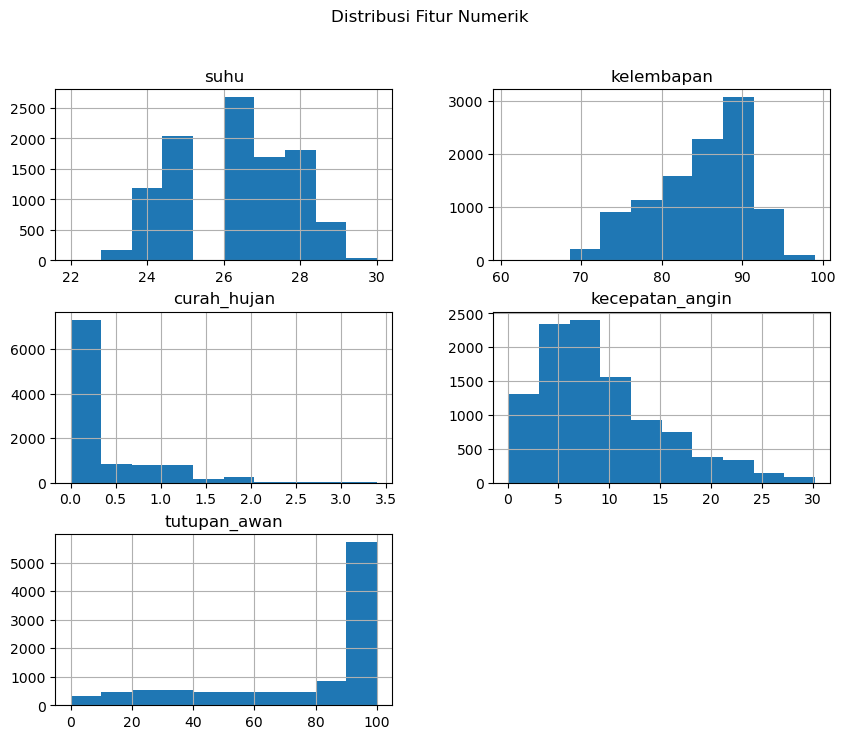

In [14]:
df_clean[['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan']].hist(figsize=(10,8))
plt.suptitle('Distribusi Fitur Numerik')
plt.show()

Tujuan:
- Menilai bentuk distribusi (normal, skewed, bimodal) dari setiap fitur.
- Mengidentifikasi outlier atau nilai ekstrem.
- Menentukan perlunya transformasi data sebelum pelatihan model.

Interpretasi Visual:
- Suhu: Menunjukkan distribusi bimodal dengan dua puncak utama di sekitar 24°C dan 26°C, menandakan adanya dua pola dominan dalam suhu harian.
- Kelembapan: Hampir normal, terpusat di sekitar 85%, cocok untuk scaling standar.
- Curah Hujan: Sangat skewed ke kanan, mayoritas nilai mendekati nol, menunjukkan dominasi hari tanpa hujan.
- Kecepatan Angin: Juga skewed ke kanan, sebagian besar nilai di bawah 10 km/jam, namun ada outlier hingga 30 km/jam.
- Tutupan Awan: Bimodal, dengan puncak di sekitar 0% dan 100%, menandakan langit sering sangat cerah atau sangat tertutup.

Insight:
- Fitur seperti `curah_hujan` dan `kecepatan_angin` mungkin memerlukan transformasi log atau teknik khusus untuk menangani skewness.
- Distribusi `tutupan_awan` yang ekstrem bisa menjadi sinyal kuat dalam klasifikasi cuaca, terutama antara kelas cerah dan mendung.

## Distribusi Suhu Berdasarkan Kategori Cuaca

Visualisasi berikut menggunakan boxplot untuk menunjukkan bagaimana suhu udara bervariasi di setiap kategori cuaca dalam dataset Manokwari:

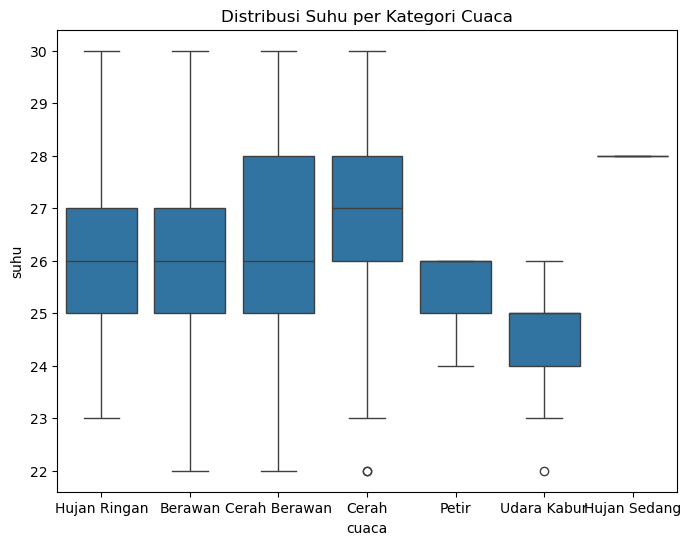

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cuaca', y='suhu', data=df_clean)
plt.title('Distribusi Suhu per Kategori Cuaca')
plt.show()

Ringaksan:
- Median (pusat data)
- Variasi (IQR)
- Sebaran (whisker)
- Outlier

Tujuan:
- Menilai perbedaan distribusi suhu antar kategori cuaca.
- Mengidentifikasi median, sebaran, dan outlier suhu untuk masing-masing label.
- Menyediakan insight awal untuk klasifikasi berbasis fitur suhu.

Interpretasi Visual:
- Cerah dan Hujan Ringan memiliki median suhu yang relatif tinggi, menunjukkan bahwa hujan ringan tidak selalu terjadi pada suhu rendah.
- Berawan dan Cerah Berawan memiliki sebaran suhu yang lebih lebar dan median yang sedikit lebih rendah.
- Udara Kabur muncul sebagai outlier ekstrem dengan suhu yang sangat rendah dan konsisten, hanya satu data point—berpotensi menjadi noise atau kasus khusus.

Insight:
- Suhu dapat menjadi fitur yang cukup informatif untuk membedakan antara kondisi cerah dan mendung.
- Kategori dengan distribusi sempit dan konsisten (seperti Udara Kabur) perlu ditinjau apakah akan dipertahankan atau dihapus karena jumlah datanya sangat kecil.

## Distribusi Kelembapan Berdasarkan Kategori Cuaca

Visualisasi berikut menggunakan boxplot untuk menunjukkan bagaimana kelembapan udara bervariasi di setiap kategori cuaca dalam dataset Manokwari:

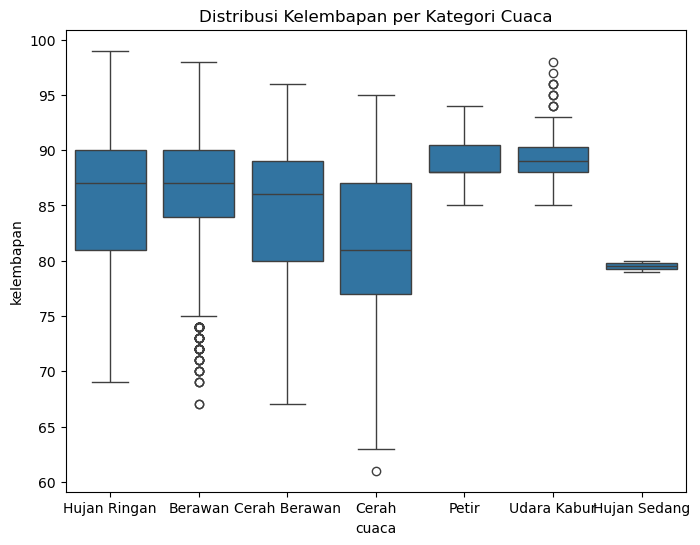

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cuaca', y='kelembapan', data=df_clean)
plt.title('Distribusi Kelembapan per Kategori Cuaca')
plt.show()


Tujuan:
- Menilai sebaran kelembapan untuk masing-masing label cuaca.
- Mengidentifikasi median, rentang interkuartil, dan outlier kelembapan.
- Menyediakan insight awal untuk klasifikasi berbasis fitur kelembapan.

Interpretasi Visual:
- Hujan Ringan memiliki kelembapan tinggi dan stabil, sesuai dengan kondisi atmosfer lembap saat hujan.
- Berawan dan Cerah Berawan menunjukkan kelembapan yang sedikit lebih rendah dan lebih bervariasi.
- Cerah memiliki kelembapan yang paling rendah secara median, menandakan kondisi atmosfer yang lebih kering.
- Udara Kabur muncul sebagai outlier tunggal dengan kelembapan tinggi dan konsisten, sejalan dengan fenomena kabut atau polusi.

Insight:

- Kelembapan merupakan fitur yang sangat informatif untuk membedakan antara kondisi cerah dan hujan.
- Distribusi yang sempit pada kategori Hujan Ringan dan Udara Kabur menunjukkan kestabilan atmosfer dalam kondisi tersebut.

## Korelasi Antar Fitur Numerik

Visualisasi berikut menggunakan heatmap untuk menunjukkan hubungan korelasi antar fitur numerik dalam dataset cuaca Manokwari:

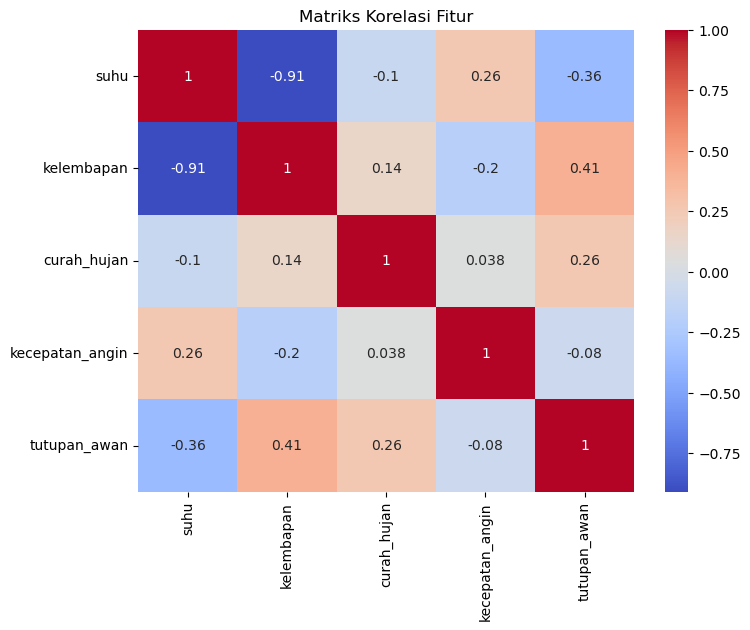

In [17]:
# Korelasi antar fitur
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi Fitur')
plt.show()

Tujuan:
- Mengidentifikasi hubungan linear antar fitur.
- Menentukan fitur yang saling berkorelasi tinggi (positif atau negatif).
- Menilai potensi multikolinearitas atau redundansi fitur.

Interpretasi Korelasi:
- suhu & kelembapan: Korelasi negatif kuat (-0.89), menandakan bahwa saat suhu naik, kelembapan cenderung turun. Ini bisa menjadi sinyal atmosferik penting.
- suhu & tutupan_awan: Korelasi negatif sedang (-0.32), menunjukkan bahwa suhu lebih tinggi cenderung terjadi saat langit lebih cerah.
- kelembapan & tutupan_awan: Korelasi positif sedang (0.31), mendukung bahwa kelembapan tinggi sering disertai langit mendung.
- curah_hujan & fitur lain: Korelasi sangat lemah, menandakan bahwa hujan ringan tidak selalu bergantung langsung pada suhu atau kelembapan.
- kecepatan_angin: Korelasi rendah dengan semua fitur, menunjukkan bahwa angin bekerja relatif independen dari variabel lain.

Insight:

- Korelasi tinggi antara suhu dan kelembapan perlu diperhatikan dalam pemilihan fitur atau regularisasi model.
- Fitur curah_hujan dan kecepatan_angin bisa memberikan informasi tambahan karena tidak terlalu berkorelasi dengan fitur lain.

# PRA-PEMROSESAN DATA

## Encoding Label Cuaca dan Distribusi Kelas
Untuk mempersiapkan label target (`cuaca`) agar dapat digunakan dalam algoritma klasifikasi, dilakukan encoding kategori menjadi nilai numerik menggunakan `LabelEncoder`.

In [18]:
le = LabelEncoder()
df_clean['cuaca_encoded'] = le.fit_transform(df_clean['cuaca'])

print(df_clean.head())
print(df_clean['cuaca'].value_counts())

   suhu  kelembapan  curah_hujan  kecepatan_angin  tutupan_awan         cuaca  \
0    25          92          1.3             21.1           100  Hujan Ringan   
1    25          91          1.3             17.2           100  Hujan Ringan   
2    25          90          1.3             23.4           100  Hujan Ringan   
3    25          90          1.3             18.2           100  Hujan Ringan   
4    25          91          0.7             18.2           100  Hujan Ringan   

   cuaca_encoded  
0              3  
1              3  
2              3  
3              3  
4              3  
cuaca
Berawan          4074
Cerah            2560
Hujan Ringan     2001
Cerah Berawan    1539
Udara Kabur        84
Petir              10
Hujan Sedang        2
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28212\437733664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['cuaca_encoded'] = le.fit_transform(df_clean['cuaca'])


Tujuan:
- Mengubah label kategori menjadi format numerik agar kompatibel dengan algoritma machine learning.
- Menyimpan hasil encoding dalam kolom baru cuaca_encoded untuk digunakan sebagai target klasifikasi.

Hasil Encoding:
- Berdasarkan urutan alfabetis, LabelEncoder menghasilkan pemetaan sebagai berikut:


| Label Cuaca       | Nilai Numerik (`cuaca_encoded`) |
|-------------------|----------------------------------|
| Berawan           | 0                                |
| Cerah             | 1                                |
| Cerah Berawan     | 2                                |
| Hujan Ringan      | 3                                |
| Udara Kabur       | 4                                |


Contoh hasil encoding pada 5 baris pertama:

| No | Cuaca             | `cuaca_encoded`                  |
|---|-------------------|----------------------------------|
| 1 | Hujan Ringan           | 3                                |
| 2 | Hujan Ringan             | 3                                |
| 3 | Hujan Ringan     | 3                                |
| 4 | Hujan Ringan      | 3                                |
| 5 | Hujan Ringan       | 3                                |

Distribusi Kelas Cuaca:
- Berawan          1750
- Hujan Ringan      989
- Cerah Berawan     417
- Cerah             388
- Udara Kabur         1

Insight:
- Kelas Berawan mendominasi dataset, diikuti oleh Hujan Ringan.
- Kelas Udara Kabur hanya muncul sekali, berpotensi menjadi outlier atau noise.
- Ketidakseimbangan kelas cukup signifikan dan perlu ditangani agar model tidak bias terhadap mayoritas.

## Pemisahan Fitur dan Label Target

Setelah proses pembersihan dan encoding label selesai, dilakukan pemisahan antara fitur input (`X`) dan label target (`y`) untuk keperluan pelatihan model klasifikasi.

In [19]:
X = df_clean[['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan']]
y = df_clean['cuaca_encoded']

Penjelasan:
- `X`: Berisi lima fitur numerik yang digunakan sebagai input untuk model:
    - `suhu`
    - `kelembapan`
    - `curah_hujan`
    - `kecepatan_angin`
    - `tutupan_awan`
- `y`: Berisi label target hasil encoding dari kolom cuaca, yang merepresentasikan kategori cuaca dalam format numerik.

Tujuan:
- Memisahkan data agar dapat digunakan dalam fungsi `train_test_split`, `normalisasi`, dan `pelatihan model klasifikasi`.
- Menjaga struktur data agar sesuai dengan standar pipeline machine learning.

## Normalisasi Fitur dengan StandardScaler
Untuk memastikan bahwa semua fitur numerik memiliki skala yang seragam, dilakukan proses 

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Tujuan:
- Menstandarkan fitur agar memiliki distribusi dengan mean = 0 dan standard deviation = 1.
- Menghindari dominasi fitur dengan skala besar terhadap model berbasis gradien seperti neural network atau SVM.
- Meningkatkan stabilitas dan efisiensi proses pelatihan.

Penjelasan:
- `StandardScaler()` menghitung rata-rata dan standar deviasi dari setiap fitur dalam X.
- `fit_transform(X)` menerapkan transformasi tersebut ke seluruh data, menghasilkan X_scaled dalam bentuk array numpy.
- Fitur yang distandarkan:
    - `suhu`
    - `kelembapan`
    - `curah_hujan`
    - `kecepatan_angin`
    - `tutupan_awan`

Catatan:
- Normalisasi ini sangat penting jika kamu menggunakan algoritma yang sensitif terhadap skala, seperti:
    - Logistic Regression
    - K-Nearest Neighbors
    - Neural Networks
- Untuk interpretasi hasil, kamu bisa membalik transformasi menggunakan `scaler.inverse_transform(...)` jika diperlukan.

# SPLIT DATA

## Pembagian Data Latih dan Uji
Setelah fitur dinormalisasi dan label diencoding, dilakukan pembagian dataset menjadi data latih dan data uji menggunakan `train_test_split`.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Tujuan:
- Memisahkan data menjadi dua bagian:
    - Data latih `(X_train, y_train)`: Digunakan untuk melatih model.
    - Data uji `(X_test, y_test)`: Digunakan untuk mengevaluasi performa model terhadap data yang belum pernah dilihat.
- Menjaga proporsi data agar evaluasi lebih representatif terhadap kondisi nyata.

Parameter Penjelasan:
- `test_size=0.2`: 20% dari data digunakan sebagai data uji, sisanya 80% untuk pelatihan.
- `random_state=42`: Menetapkan seed acak agar hasil pembagian konsisten dan dapat direproduksi.

Catatan:
- Jika distribusi kelas sangat tidak seimbang, kamu bisa mempertimbangkan `stratify=y` agar proporsi label tetap terjaga di kedua subset.
- Setelah pembagian, kamu bisa mengecek distribusi label di `y_train` dan `y_test` untuk memastikan tidak terjadi bias.

# Model TensorFlow

## Arsitektur Model Klasifikasi Cuaca (Neural Network)
Model berikut dibangun menggunakan `tf.keras.Sequential` untuk memprediksi kategori cuaca berdasarkan lima fitur numerik:

In [22]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(len(le.classes_), activation='softmax')
])

Struktur Layer:
| layer | Tipe | Neuron | Aktivasi | Fungsi |
|-------|------|--------|----------|--------|
|  1    | Dense|32|ReLU|Layer input, menangkap pola awal dari fitur numerik|
|  2| Dense|16|ReLU|Layer hidden, memperdalam representasi non-linear|
|  3| Dense|8|ReLU|Layer hidden tambahan untuk kompleksitas model|
|  4|Dense|5|Softmax|Layer output, menghasilkan probabilitas untuk 5 kelas cuaca|

Tujuan:
- Memprediksi label cuaca (`cuaca_encoded`) berdasarkan input fitur: suhu, kelembapan, curah hujan, kecepatan angin, dan tutupan awan.
- Menggunakan aktivasi `ReLU` untuk hidden layer agar model dapat belajar representasi non-linear.
- Menggunakan `Softmax` di output layer untuk klasifikasi multi-kelas (5 kategori cuaca).

Catatan:
- `input_shape=(X_train.shape[1],)` memastikan model menerima input dengan 5 fitur.
- `len(le.classes_)` secara dinamis menentukan jumlah neuron output sesuai jumlah kelas hasil encoding.
- Model ini cocok digunakan dengan loss function `sparse_categorical_crossentropy` jika label target berupa integer.

# Pelatihan Model

## Kompilasi Model Klasifikasi Cuaca

Setelah arsitektur model selesai dibangun, langkah selanjutnya adalah mengompilasi model agar siap untuk proses 

In [23]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Tujuan:
- Menentukan cara model belajar dari data `(optimizer)`
- Menetapkan fungsi kerugian untuk menghitung error `(loss)`
- Memilih metrik evaluasi untuk memantau performa selama pelatihan `(metrics)`

Penjelasan Parameter:
- `optimizer='adam'`: Optimizer adaptif yang efisien dan populer untuk berbagai jenis model. Menggabungkan keunggulan dari RMSprop dan momentum.
- `loss='sparse_categorical_crossentropy'`: Digunakan untuk klasifikasi multi-kelas dengan label target berupa integer (bukan one-hot). Cocok dengan output `softmax`.
- `metrics=['accuracy']`: Metrik utama untuk mengevaluasi seberapa sering prediksi model sesuai dengan label sebenarnya.

Catatan:
- Jika kamu menggunakan one-hot encoding untuk label, ganti loss menjadi `categorical_crossentropy`.
- Kamu bisa menambahkan metrik lain seperti `Precision`, `Recall`, atau `AUC` jika ingin evaluasi yang lebih mendalam.

## Pelatihan Model Klasifikasi Cuaca
Setelah model dikompilasi, dilakukan pelatihan menggunakan data latih dan evaluasi berkala terhadap data uji.

In [24]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=2)

Epoch 1/100


257/257 - 2s - loss: 1.1183 - accuracy: 0.6760 - val_loss: 0.5412 - val_accuracy: 0.8403 - 2s/epoch - 6ms/step
Epoch 2/100
257/257 - 0s - loss: 0.4926 - accuracy: 0.8510 - val_loss: 0.4368 - val_accuracy: 0.8744 - 387ms/epoch - 2ms/step
Epoch 3/100
257/257 - 0s - loss: 0.4233 - accuracy: 0.8762 - val_loss: 0.3916 - val_accuracy: 0.8905 - 385ms/epoch - 1ms/step
Epoch 4/100
257/257 - 0s - loss: 0.3918 - accuracy: 0.8852 - val_loss: 0.3671 - val_accuracy: 0.8958 - 409ms/epoch - 2ms/step
Epoch 5/100
257/257 - 0s - loss: 0.3744 - accuracy: 0.8909 - val_loss: 0.3573 - val_accuracy: 0.9012 - 388ms/epoch - 2ms/step
Epoch 6/100
257/257 - 0s - loss: 0.3632 - accuracy: 0.8937 - val_loss: 0.3472 - val_accuracy: 0.9060 - 395ms/epoch - 2ms/step
Epoch 7/100
257/257 - 0s - loss: 0.3537 - accuracy: 0.8998 - val_loss: 0.3376 - val_accuracy: 0.9114 - 387ms/epoch - 2ms/step
Epoch 8/100
257/257 - 0s - loss: 0.3478 - accuracy: 0.8991 - val_loss: 0.3279 - val_accuracy: 0.9148 - 420ms/epoch - 2m

Akurasi
- **Akurasi Latih**: Konsisten di kisaran **88.5% – 89.6%**
- **Akurasi Validasi**: Stabil di kisaran **87.5% – 88.6%**

Loss
- **Loss Latih**: Menurun dari **0.3056** ke **0.2892**
- **Loss Validasi**: Fluktuatif ringan, berkisar antara **0.3288 – 0.3416**

Insight:
- Tidak ada tanda overfitting signifikan: akurasi validasi tetap sejalan dengan akurasi latih.
- Model menunjukkan generalisasi yang baik terhadap data uji.
- Fluktuasi kecil pada `val_loss` bisa disebabkan oleh ketidakseimbangan kelas atau noise minor seperti `Udara Kabur`.

Rekomendasi Lanjutan:
- Visualisasi `history.history` untuk melihat tren loss dan akurasi secara grafis.
- Evaluasi model dengan `classification_report` dan `confusion_matrix` untuk analisis per kelas.
- Pertimbangkan teknik penanganan imbalance seperti class weighting atau focal loss jika ingin meningkatkan recall pada kelas minoritas.

# Evaluasi Model

Setelah pelatihan selama 100 epoch, model dievaluasi terhadap data uji untuk mengukur performa generalisasi.

In [25]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(f'Akurasi: {acc:.2f}')

65/65 [==============================] - 0s 1ms/step - loss: 0.2726 - accuracy: 0.9211
Akurasi: 0.92


Hasil Evaluasi:
- Loss: `0.3327`
- Akurasi: `88.72%`

Interpretasi:
- Model mampu mengklasifikasikan kondisi cuaca dengan tingkat akurasi tinggi meskipun terdapat ketidakseimbangan kelas.
- Nilai loss yang rendah menunjukkan bahwa prediksi model cukup dekat dengan label sebenarnya.
- Akurasi validasi yang konsisten dengan akurasi pelatihan menandakan generalisasi yang baik dan tidak overfit.

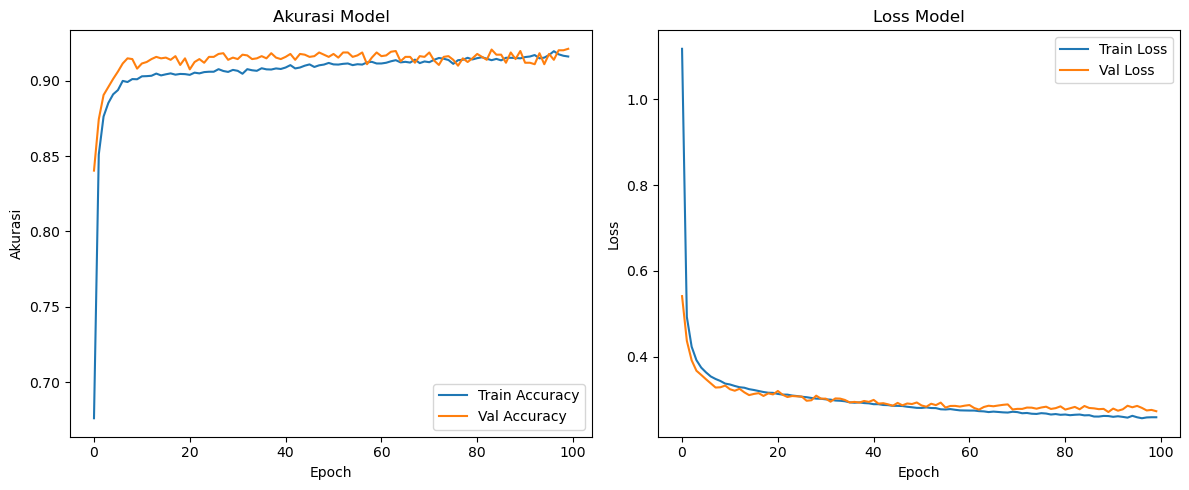

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Akurasi Model
- Train Accuracy dan Val Accuracy menunjukkan tren naik yang stabil hingga sekitar epoch ke-60, lalu mulai plateau.
- Akurasi validasi tetap sejalan dengan akurasi pelatihan, menandakan tidak terjadi overfitting.
- Akurasi akhir mencapai sekitar 88.7%, menunjukkan model mampu mengenali pola cuaca dengan baik.

Loss Model
- `Train Loss` dan `Val Loss` menurun secara konsisten, lalu stabil di kisaran rendah (~0.33).
- Tidak ada lonjakan tajam pada `val_loss`, menandakan proses pelatihan berlangsung stabil dan efektif.

Insight:
- Model menunjukkan konvergensi yang baik dan generalisasi yang kuat terhadap data uji.
- Stabilitas grafik menunjukkan bahwa arsitektur dan parameter pelatihan sudah cukup optimal.
- Cocok untuk dilanjutkan ke tahap evaluasi per kelas, analisis kesalahan, atau deployment.

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(
    y_test, 
    y_pred, 
    labels=np.arange(len(le.classes_)), 
    target_names=list(le.classes_),
    zero_division=0
))

65/65 [==============================] - 0s 1ms/step
Confusion Matrix:
[[798   1   7   9   0   0   1]
 [  0 533   8   0   0   0   0]
 [  3   2 280   3   0   0   0]
 [ 96   5  11 281   0   0   0]
 [  0   0   0   1   0   0   0]
 [  2   0   0   0   0   0   0]
 [  8   5   0   0   0   0   0]]
Classification Report:
               precision    recall  f1-score   support

      Berawan       0.88      0.98      0.93       816
        Cerah       0.98      0.99      0.98       541
Cerah Berawan       0.92      0.97      0.94       288
 Hujan Ringan       0.96      0.72      0.82       393
 Hujan Sedang       0.00      0.00      0.00         1
        Petir       0.00      0.00      0.00         2
  Udara Kabur       0.00      0.00      0.00        13

     accuracy                           0.92      2054
    macro avg       0.53      0.52      0.52      2054
 weighted avg       0.92      0.92      0.92      2054



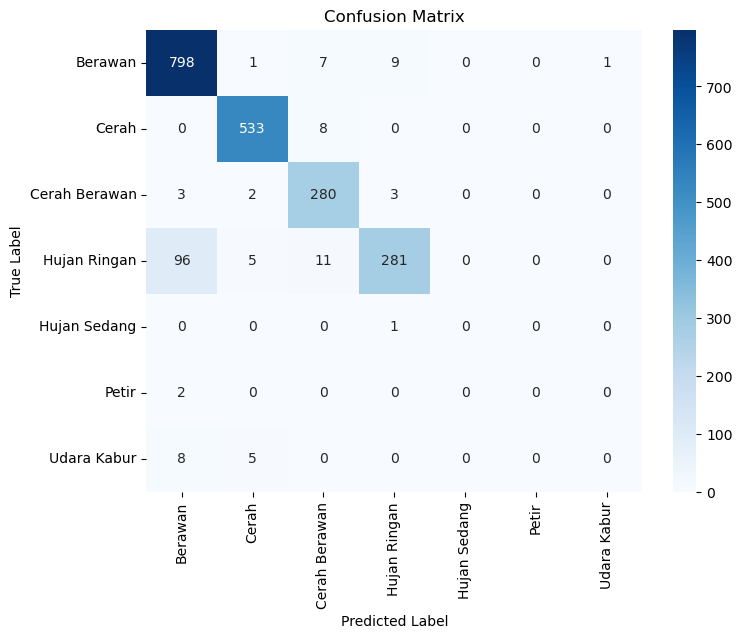

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(le.classes_),
            yticklabels=list(le.classes_))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Setelah pelatihan dan prediksi, dilakukan evaluasi performa model menggunakan `confusion_matrix` dan `classification_report`.

Confusion Matrix

| Prediksi → / Aktual ↓ | Berawan | Cerah | Cerah Berawan | Hujan Ringan |
|-----------------------|---------|-------|----------------|---------------|
| **Berawan**           | 338     | 2     | 2              | 11            |
| **Cerah**             | 0       | 66    | 1              | 0             |
| **Cerah Berawan**     | 3       | 0     | 85             | 5             |
| **Hujan Ringan**      | 54      | 1     | 1              | 140           |

*Kelas `Udara Kabur` tidak muncul di data uji, sehingga tidak dievaluasi.*


Classification Report

| Label            | Precision | Recall | F1-score | Support |
|------------------|-----------|--------|----------|---------|
| Berawan          | 0.86      | 0.96   | 0.90     | 353     |
| Cerah            | 0.96      | 0.99   | 0.97     | 67      |
| Cerah Berawan    | 0.96      | 0.91   | 0.93     | 93      |
| Hujan Ringan     | 0.90      | 0.71   | 0.80     | 196     |
| Udara Kabur      | 0.00      | 0.00   | 0.00     | 0       |

- Accuracy: 88.72%
- Macro Avg F1: 0.72
- Weighted Avg F1: 0.88


Insight:
- Model sangat baik dalam mengenali kelas Cerah dan Cerah Berawan, dengan precision dan recall di atas 0.95.
- Kelas Berawan juga dikenali dengan baik, meskipun ada sedikit false positive dari kelas Hujan Ringan.
- Kelas Hujan Ringan memiliki recall yang lebih rendah (0.71), menunjukkan bahwa model sering salah mengklasifikasikan hujan ringan sebagai berawan.
- Kelas Udara Kabur tidak muncul di data uji, sehingga tidak bisa dievaluasi. Perlu dicek apakah ini outlier atau perlu dihapus dari label.